# Test synthcity and syntheval with toy dataset

This notebook is for testing tabular synthetic data generation via [synthcity](https://github.com/schneiderkamplab/synthcity) and evaluation via synthcity and [syntheval](https://github.com/schneiderkamplab/syntheval) using the [hepatitis](https://epistasislab.github.io/pmlb/profile/hepatitis.html) dataset from `pmlb`.

## Import libraries and load the data

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pmlb import fetch_data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.unsupervised import TabPFNUnsupervisedModel
from tabpfgen import TabPFGen

from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader
from synthcity.benchmark import Benchmarks

from syntheval import SynthEval, AnalysisConfig

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
hepatitis_df: pd.DataFrame = fetch_data("hepatitis", local_cache_dir="../data")

print(f"Dataset shape: {hepatitis_df.shape}")
print(f"\nColumns: {hepatitis_df.columns.tolist()}")
hepatitis_df.head()

Dataset shape: (155, 20)

Columns: ['AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME', 'HISTOLOGY', 'target']


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,36.0,1,1,2,1,1,1,1,1,1,1,1,1,3,10,44,16,44,2,2
1,45.0,1,1,1,1,1,1,1,1,1,1,1,1,10,76,55,18,42,2,2
2,47.0,1,0,1,1,1,1,1,1,1,1,1,1,34,83,67,29,44,1,2
3,36.0,1,0,2,1,1,1,1,1,0,1,1,1,5,76,55,18,42,1,2
4,50.0,1,1,2,1,1,1,1,1,1,1,1,1,7,19,78,15,27,2,2


In [3]:
hepatitis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AGE              155 non-null    float64
 1   SEX              155 non-null    int64  
 2   STEROID          155 non-null    int64  
 3   ANTIVIRALS       155 non-null    int64  
 4   FATIGUE          155 non-null    int64  
 5   MALAISE          155 non-null    int64  
 6   ANOREXIA         155 non-null    int64  
 7   LIVER BIG        155 non-null    int64  
 8   LIVER FIRM       155 non-null    int64  
 9   SPLEEN PALPABLE  155 non-null    int64  
 10  SPIDERS          155 non-null    int64  
 11  ASCITES          155 non-null    int64  
 12  VARICES          155 non-null    int64  
 13  BILIRUBIN        155 non-null    int64  
 14  ALK PHOSPHATE    155 non-null    int64  
 15  SGOT             155 non-null    int64  
 16  ALBUMIN          155 non-null    int64  
 17  PROTIME         

In [4]:
hepatitis_df.describe().round(3)

,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
count,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000,155.000
mean,41.200,1.103,0.516,1.845,0.361,0.613,0.800,0.903,0.684,0.839,0.703,0.903,0.916,10.787,54.090,46.658,15.819,30.729,1.452,1.794
std,12.566,0.305,0.514,0.363,0.495,0.502,0.417,0.467,0.600,0.448,0.524,0.391,0.377,8.855,27.237,23.027,7.090,15.424,0.499,0.406
min,7.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000
25%,32.000,1.000,0.000,2.000,0.000,0.000,1.000,1.000,0.000,1.000,0.000,1.000,1.000,5.000,30.500,28.000,11.000,19.000,1.000,2.000
50%,39.000,1.000,1.000,2.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,7.000,64.000,48.000,16.000,38.000,1.000,2.000
75%,50.000,1.000,1.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,13.000,76.000,66.500,19.000,44.000,2.000,2.000
max,78.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,34.000,83.000,84.000,29.000,44.000,2.000,2.000


In [5]:
# Check distributions in categorical columns (with less than 10 unique values)
categorical_cols: list[str] = [
    _col for _col in hepatitis_df.columns if hepatitis_df[_col].nunique() < 10
]
print(f"\nCategorical columns: {categorical_cols}")

for _col in categorical_cols:
    print(f"\nDistribution of {_col}:")
    print(hepatitis_df[_col].value_counts())


Categorical columns: ['SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'HISTOLOGY', 'target']

Distribution of SEX:
SEX
1    139
2     16
Name: count, dtype: int64

Distribution of STEROID:
STEROID
1    78
0    76
2     1
Name: count, dtype: int64

Distribution of ANTIVIRALS:
ANTIVIRALS
2    131
1     24
Name: count, dtype: int64

Distribution of FATIGUE:
FATIGUE
0    100
1     54
2      1
Name: count, dtype: int64

Distribution of MALAISE:
MALAISE
1    93
0    61
2     1
Name: count, dtype: int64

Distribution of ANOREXIA:
ANOREXIA
1    122
0     32
2      1
Name: count, dtype: int64

Distribution of LIVER BIG:
LIVER BIG
1    120
0     25
2     10
Name: count, dtype: int64

Distribution of LIVER FIRM:
LIVER FIRM
1    84
0    60
2    11
Name: count, dtype: int64

Distribution of SPLEEN PALPABLE:
SPLEEN PALPABLE
1    120
0     30
2      5
Name: count, dtype: int64

Distribution of SPIDERS:
S

In [6]:
target_column = "target"
print(f"Target column: {target_column}")
print("\nTarget distribution (%):")
print(hepatitis_df[target_column].value_counts(normalize=True) * 100)

Target column: target

Target distribution (%):
target
2    79.354839
1    20.645161
Name: proportion, dtype: float64


## Train/test split

In [7]:
train_df, test_df = train_test_split(
    hepatitis_df,
    train_size=2 / 3,
    random_state=42,
    stratify=hepatitis_df[target_column],
)

train_df.to_csv("../data/hepatitis/train.csv", index=False)
test_df.to_csv("../data/hepatitis/test.csv", index=False)

print(
    f"Training set size: {len(train_df)} ({len(train_df) / len(hepatitis_df) * 100:.1f}%)"
)
print(
    f"Testing set size: {len(test_df)} ({len(test_df) / len(hepatitis_df) * 100:.1f}%)"
)
print("\nTraining set target distribution:")
print(train_df[target_column].value_counts())
print("\nTesting set target distribution:")
print(test_df[target_column].value_counts())
print("\nTraining set sex distribution:")
print(train_df["SEX"].value_counts())
print("\nTesting set sex distribution:")
print(test_df["SEX"].value_counts())

Training set size: 103 (66.5%)
Testing set size: 52 (33.5%)

Training set target distribution:
target
2    82
1    21
Name: count, dtype: int64

Testing set target distribution:
target
2    41
1    11
Name: count, dtype: int64

Training set sex distribution:
SEX
1    93
2    10
Name: count, dtype: int64

Testing set sex distribution:
SEX
1    46
2     6
Name: count, dtype: int64


## Create synthcity DataLoader

In [8]:
train_loader = GenericDataLoader(
    train_df,
    target_column=target_column,
    sensitive_features=["AGE", "SEX"],
    fairness_column="SEX",
    random_state=42,
)

test_loader = GenericDataLoader(
    test_df,
    target_column=target_column,
    sensitive_features=["AGE", "SEX"],
    fairness_column="SEX",
    random_state=42,
)

print("DataLoader created successfully")
print(f"Shape: {train_loader.shape}")
print(f"Columns: {train_loader.columns}")

DataLoader created successfully
Shape: (103, 20)
Columns: ['AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME', 'HISTOLOGY', 'target']


## Generate synthetic data with multiple models

In [9]:
print("Available synthcity plugins:")
Plugins().list()

Available synthcity plugins:


[2026-06-26T14:36:52.858582+0300][89846][CRITICAL] load failed: module 'pyarrow' has no attribute 'PyExtensionType'
[2026-06-26T14:36:52.859147+0300][89846][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-06-26T14:36:52.859301+0300][89846][CRITICAL] module plugin_great load failed
[2026-06-26T14:36:52.866922+0300][89846][CRITICAL] Error importing TabularGoggle: No module named 'dgl'
[2026-06-26T14:36:52.868343+0300][89846][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


['uniform_sampler',
 'pategan',
 'ctgan',
 'timevae',
 'arf',
 'nflow',
 'dpgan',
 'bayesian_network',
 'adsgan',
 'rtvae',
 'marginal_distributions',
 'dummy_sampler',
 'aim',
 'tvae',
 'decaf',
 'fflows',
 'ddpm',
 'survival_ctgan',
 'survival_nflow',
 'timegan',
 'image_adsgan',
 'syn_seq',
 'privbayes',
 'image_cgan',
 'survae',
 'survival_gan',
 'radialgan']

In [10]:
model_names = [
    "ctgan",
    "tvae",
    "adsgan",
    "bayesian_network",
    "pategan",
    "rtvae",
    "ddpm",
]  # Removed "privbayes" and "decaf" due to issues with training on this dataset

synthetic_datasets = {}
trained_models = {}

n_samples = 200

print(
    f"Training {len(model_names)} models and generating {n_samples} synthetic samples each"
)
print("Models to be trained:")
for _model_name in model_names:
    print(f"- {_model_name}")

Training 7 models and generating 200 synthetic samples each
Models to be trained:
- ctgan
- tvae
- adsgan
- bayesian_network
- pategan
- rtvae
- ddpm


In [11]:
output_dir = "../output/hepatitis/synthetic_data"
os.makedirs(output_dir, exist_ok=True)

synthetic_data_paths = {
    model_name: os.path.join(output_dir, f"{model_name}.csv")
    for model_name in model_names
}

print(f"Synthetic data output directory: {output_dir}")
for model_name, path in synthetic_data_paths.items():
    print(f"- {model_name}: {path}")

Synthetic data output directory: ../output/hepatitis/synthetic_data
- ctgan: ../output/hepatitis/synthetic_data/ctgan.csv
- tvae: ../output/hepatitis/synthetic_data/tvae.csv
- adsgan: ../output/hepatitis/synthetic_data/adsgan.csv
- bayesian_network: ../output/hepatitis/synthetic_data/bayesian_network.csv
- pategan: ../output/hepatitis/synthetic_data/pategan.csv
- rtvae: ../output/hepatitis/synthetic_data/rtvae.csv
- ddpm: ../output/hepatitis/synthetic_data/ddpm.csv


In [12]:
for _model_name in model_names:
    output_path = synthetic_data_paths[_model_name]
    if os.path.exists(output_path):
        print(f"\nFound cached synthetic data for {_model_name}: {output_path}")
        synthetic_data = pd.read_csv(output_path)
        synthetic_datasets[_model_name] = synthetic_data
        print(f"Loaded {_model_name} synthetic data, shape: {synthetic_data.shape}")
        continue

    print(f"\nTraining {_model_name}...")
    model = Plugins().get(_model_name)
    model.fit(train_loader)
    trained_models[_model_name] = model

    print(f"Generating synthetic data with {_model_name}...")
    synthetic_data = model.generate(count=n_samples, random_state=42).dataframe()
    synthetic_datasets[_model_name] = synthetic_data
    synthetic_data.to_csv(output_path, index=False)
    print(f"Saved {_model_name} synthetic data to {output_path}")
    print(f"Synthetic data generated with {_model_name}, shape: {synthetic_data.shape}")


Found cached synthetic data for ctgan: ../output/hepatitis/synthetic_data/ctgan.csv
Loaded ctgan synthetic data, shape: (200, 20)

Found cached synthetic data for tvae: ../output/hepatitis/synthetic_data/tvae.csv
Loaded tvae synthetic data, shape: (200, 20)

Found cached synthetic data for adsgan: ../output/hepatitis/synthetic_data/adsgan.csv
Loaded adsgan synthetic data, shape: (200, 20)

Found cached synthetic data for bayesian_network: ../output/hepatitis/synthetic_data/bayesian_network.csv
Loaded bayesian_network synthetic data, shape: (200, 20)

Found cached synthetic data for pategan: ../output/hepatitis/synthetic_data/pategan.csv
Loaded pategan synthetic data, shape: (200, 20)

Found cached synthetic data for rtvae: ../output/hepatitis/synthetic_data/rtvae.csv
Loaded rtvae synthetic data, shape: (200, 20)

Found cached synthetic data for ddpm: ../output/hepatitis/synthetic_data/ddpm.csv
Loaded ddpm synthetic data, shape: (200, 20)


### TabPFN synthetic data generation

In [13]:
tabpfn_model_name = "tabpfn"
tabpfn_output_path = os.path.join(output_dir, f"{tabpfn_model_name}.csv")

if os.path.exists(tabpfn_output_path):
    print(
        f"\nFound cached synthetic data for {tabpfn_model_name}: {tabpfn_output_path}"
    )
    synthetic_data = pd.read_csv(tabpfn_output_path)
    synthetic_datasets[tabpfn_model_name] = synthetic_data
    print(f"Loaded {tabpfn_model_name} synthetic data, shape: {synthetic_data.shape}")
else:
    print(f"\nTraining {tabpfn_model_name}...")

    # Identify binary columns encoded as {1, 2} and shift to {0, 1} for TabPFN
    binary_cols = [
        col
        for col in train_df.columns
        if set(train_df[col].dropna().unique()) == {1, 2}
    ]
    train_df_shifted = train_df.copy()
    train_df_shifted[binary_cols] = train_df_shifted[binary_cols] - 1

    train_array = train_df_shifted.values

    clf = TabPFNClassifier()
    reg = TabPFNRegressor()
    model_unsupervised = TabPFNUnsupervisedModel(tabpfn_clf=clf, tabpfn_reg=reg)
    model_unsupervised.fit(train_array)

    print(f"Generating synthetic data with {tabpfn_model_name}...")
    synthetic_tensor = model_unsupervised.generate_synthetic_data(n_samples=n_samples)
    synthetic_data = pd.DataFrame(synthetic_tensor.numpy(), columns=train_df.columns)

    for col in categorical_cols + [target_column]:
        synthetic_data[col] = synthetic_data[col].round().astype(int)

    # Shift binary cols back from {0, 1} to {1, 2}
    synthetic_data[binary_cols] = synthetic_data[binary_cols] + 1

    synthetic_datasets[tabpfn_model_name] = synthetic_data
    synthetic_data.to_csv(tabpfn_output_path, index=False)
    print(f"Saved {tabpfn_model_name} synthetic data to {tabpfn_output_path}")
    print(
        f"Synthetic data generated with {tabpfn_model_name}, shape: {synthetic_data.shape}"
    )


Found cached synthetic data for tabpfn: ../output/hepatitis/synthetic_data/tabpfn.csv
Loaded tabpfn synthetic data, shape: (200, 20)


### TabPFGen synthetic data generation

In [14]:
class TabPFGenSGLDLabels(TabPFGen):
    """TabPFGen variant that keeps the SGLD class assignments as final labels.

    TabPFGen's built-in ``generate_classification`` re-assigns labels at the
    end using a TabPFN classifier. TabPFN is an in-context learner; when test
    points are close to (but not identical to) training points it produces
    unstable predictions and collapses all generated labels to a single class,
    regardless of SGLD parameters. This subclass skips that final step and
    returns the class label each sample was assigned during SGLD, which is the
    class it was initialised from and guided toward throughout the chain.
    """

    def generate_classification(
        self, X_train, y_train, n_samples, balance_classes=True
    ):
        X_scaled = self.scaler.fit_transform(X_train)
        x_train = torch.tensor(X_scaled, device=self.device, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, device=self.device)

        if balance_classes:
            classes = np.unique(y_train)
            n_per_class = n_samples // len(classes)
            x_parts, y_parts = [], []
            for cls in classes:
                idx = np.where(y_train == cls)[0]
                sample_idx = np.random.choice(idx, size=n_per_class)
                x_parts.append(
                    x_train[sample_idx]
                    + torch.randn(n_per_class, X_train.shape[1], device=self.device)
                    * 0.01
                )
                y_parts.append(torch.full((n_per_class,), cls, device=self.device))
            x_synth = torch.cat(x_parts)
            y_synth = torch.cat(y_parts)
        else:
            x_synth = (
                torch.randn(n_samples, X_train.shape[1], device=self.device) * 0.01
            )
            y_synth = torch.randint(
                0, len(np.unique(y_train)), (n_samples,), device=self.device
            )

        for step in range(self.n_sgld_steps):
            x_synth = self._sgld_step(x_synth, y_synth, x_train, y_train_t)
            if step % 100 == 0:
                print(f"Step {step}/{self.n_sgld_steps}")

        X_synth_out = self.scaler.inverse_transform(x_synth.detach().cpu().numpy())
        return X_synth_out, y_synth.cpu().numpy()


tabpfgen_model_name = "tabpfgen"
tabpfgen_output_path = os.path.join(output_dir, f"{tabpfgen_model_name}.csv")

if os.path.exists(tabpfgen_output_path):
    print(
        f"\nFound cached synthetic data for {tabpfgen_model_name}: {tabpfgen_output_path}"
    )
    synthetic_data = pd.read_csv(tabpfgen_output_path)
    synthetic_datasets[tabpfgen_model_name] = synthetic_data
    print(f"Loaded {tabpfgen_model_name} synthetic data, shape: {synthetic_data.shape}")
else:
    print(f"\nTraining {tabpfgen_model_name}...")

    feature_cols = [col for col in train_df.columns if col != target_column]
    cat_feature_cols = [c for c in categorical_cols if c in feature_cols]

    # Encode categorical features with OrdinalEncoder ({1,2} -> {0,1})
    cat_enc = OrdinalEncoder()
    train_df_encoded = train_df[feature_cols].copy()
    train_df_encoded[cat_feature_cols] = cat_enc.fit_transform(
        train_df[cat_feature_cols]
    )
    X_train = train_df_encoded.values.astype(float)

    # Encode target with LabelEncoder ({1,2} -> {0,1})
    target_enc = LabelEncoder()
    y_train = target_enc.fit_transform(train_df[target_column].values)

    # balance_classes=True generates equal numbers per class.  To recover the
    # training class distribution we oversample and then subsample.
    # We need at least ceil(n_samples * max_class_proportion) samples per class,
    # so the total to generate is:
    #   n_classes * ceil(n_samples * max_proportion)
    train_proportions = train_df[target_column].value_counts(normalize=True)
    n_classes = len(train_proportions)
    n_per_class_needed = int(np.ceil(n_samples * train_proportions.max()))
    n_to_generate = n_per_class_needed * n_classes
    print(
        f"Generating {n_to_generate} samples ({n_per_class_needed}/class) "
        f"to subsample down to {n_samples} matching the training distribution."
    )

    generator = TabPFGenSGLDLabels(n_sgld_steps=1000, sgld_noise_scale=0.1)

    print(f"Generating synthetic data with {tabpfgen_model_name}...")
    X_synth_all, y_synth_all = generator.generate_classification(
        X_train,
        y_train,
        n_samples=n_to_generate,
        balance_classes=True,
    )

    synth_all = pd.DataFrame(X_synth_all, columns=feature_cols)

    # Round and clip categorical columns, then inverse transform back to original labels
    for i, col in enumerate(cat_feature_cols):
        n_cats = len(cat_enc.categories_[i])
        synth_all[col] = synth_all[col].round().clip(0, n_cats - 1).astype(int)
    synth_all[cat_feature_cols] = cat_enc.inverse_transform(
        synth_all[cat_feature_cols].values
    ).astype(int)

    # Decode target back to original class labels
    n_classes_enc = len(target_enc.classes_)
    synth_all[target_column] = target_enc.inverse_transform(
        pd.Series(y_synth_all.astype(int)).clip(0, n_classes_enc - 1).values
    )

    # Subsample each class proportionally to match the training distribution
    parts = []
    for orig_cls, proportion in train_proportions.items():
        n_needed = round(n_samples * proportion)
        cls_rows = synth_all[synth_all[target_column] == orig_cls]
        parts.append(cls_rows.sample(n=n_needed, replace=False, random_state=42))
    synthetic_data = (
        pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
    )

    synthetic_datasets[tabpfgen_model_name] = synthetic_data
    synthetic_data.to_csv(tabpfgen_output_path, index=False)
    print(f"Saved {tabpfgen_model_name} synthetic data to {tabpfgen_output_path}")
    print(
        f"Synthetic data generated with {tabpfgen_model_name}, shape: {synthetic_data.shape}"
    )
    print(f"Target distribution:\n{synthetic_data[target_column].value_counts()}")



Found cached synthetic data for tabpfgen: ../output/hepatitis/synthetic_data/tabpfgen.csv
Loaded tabpfgen synthetic data, shape: (200, 20)


## Check generated data

In [15]:
for model_name, syn_data in synthetic_datasets.items():
    print(f"\n{model_name.upper()} - First 5 rows:")
    display(syn_data.head(5).round(3))
    print(f"\nTarget distribution in {model_name.upper()}:")
    print(syn_data[target_column].value_counts())
    print(f"\nSex distribution in {model_name.upper()}:")
    print(syn_data["SEX"].value_counts())
    print("-------------------------------")


CTGAN - First 5 rows:


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,30.718,1,1,2,0,1,0,2,2,1,0,1,1,8,83,27,9,44,2,2
1,41.930,1,0,2,0,1,1,2,0,1,0,0,1,8,82,20,5,43,2,2
2,27.036,1,1,2,1,1,1,0,1,1,1,1,1,5,76,28,15,40,1,2
3,40.555,1,1,2,1,1,1,1,1,1,1,1,1,5,79,12,21,44,1,2
4,29.633,1,0,2,1,1,1,1,1,1,1,1,1,9,83,29,14,20,1,2



Target distribution in CTGAN:
target
2    169
1     31
Name: count, dtype: int64

Sex distribution in CTGAN:
SEX
1    196
2      4
Name: count, dtype: int64
-------------------------------

TVAE - First 5 rows:


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,31.713,1,0,2,1,1,1,0,0,1,1,1,1,3,30,28,13,44,1,2
1,32.574,1,0,2,1,1,1,1,0,1,1,1,1,4,26,21,16,44,1,2
2,38.569,1,1,2,1,1,1,0,1,1,1,1,1,6,66,32,15,39,1,2
3,47.949,1,0,2,0,0,1,1,1,1,1,1,2,7,72,29,19,42,1,2
4,34.722,1,0,2,1,1,1,1,0,1,1,1,1,7,25,26,16,18,1,2



Target distribution in TVAE:
target
2    180
1     20
Name: count, dtype: int64

Sex distribution in TVAE:
SEX
1    200
Name: count, dtype: int64
-------------------------------

ADSGAN - First 5 rows:


...


Target distribution in DDPM:
target
2    146
1     54
Name: count, dtype: int64

Sex distribution in DDPM:
SEX
1    199
2      1
Name: count, dtype: int64
-------------------------------

TABPFN - First 5 rows:


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,17.343,1,1,2,1,1,1,2,2,2,1,1,1,5.826,46.313,11.391,10.280,44.158,1,2
1,41.565,1,1,2,0,1,1,1,1,1,1,1,1,6.341,35.048,58.593,15.577,43.738,1,2
2,63.885,1,1,2,0,0,0,1,0,1,0,0,1,17.314,10.947,32.008,6.642,4.000,2,1
3,28.922,1,0,2,1,1,1,1,1,2,2,2,2,16.755,82.435,44.907,14.334,43.829,1,2
4,45.154,1,0,2,0,1,1,0,0,1,1,1,1,3.504,83.315,56.033,11.538,43.617,1,2



Target distribution in TABPFN:
target
2    163
1     37
Name: count, dtype: int64

Sex distribution in TABPFN:
SEX
1    181
2     19
Name: count, dtype: int64
-------------------------------

TABPFGEN - First 5 rows:


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,40.314,1,0,2,0,1,1,1,0,1,1,1,1,3.254,61.748,25.491,15.462,27.059,1,2
1,28.147,1,1,2,0,0,0,0,0,0,0,1,1,8.569,16.975,78.534,17.351,11.883,1,2
2,53.262,1,1,2,1,1,1,1,1,1,1,1,1,7.240,73.298,42.612,20.842,0.587,2,2
3,42.176,1,1,2,0,1,1,1,0,1,1,1,1,6.566,16.774,12.147,18.641,43.738,2,2
4,29.420,1,1,2,1,1,1,1,1,1,1,1,1,4.812,74.715,44.719,25.225,42.635,1,2



Target distribution in TABPFGEN:
target
2    159
1     41
Name: count, dtype: int64

Sex distribution in TABPFGEN:
SEX
1    183
2     17
Name: count, dtype: int64
-------------------------------


## Evaluate with synthcity benchmarks

In [16]:
model_configs = [
    ("ctgan", "ctgan", {}),
    ("tvae", "tvae", {}),
    ("adsgan", "adsgan", {}),
    ("bayesian_network", "bayesian_network", {}),
    ("pategan", "pategan", {}),
    ("rtvae", "rtvae", {}),
    ("ddpm", "ddpm", {}),
    # ("tabpfn", "tabpfn", {})
    # ("tabpfgen", "tabpfgen", {})
]

score = Benchmarks.evaluate(
    tests=model_configs,
    X=train_loader,
    X_test=test_loader,
    synthetic_size=n_samples,
    task_type="classification",
    repeats=2,
)
Benchmarks.print(score)


Comparatives


,ctgan,tvae,adsgan,bayesian_network,pategan,rtvae,ddpm
sanity.data_mismatch.score,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0
sanity.common_rows_proportion.score,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0
sanity.nearest_syn_neighbor_distance.mean,0.452 ± 0.077,0.426 ± 0.024,0.457 ± 0.001,0.433 ± 0.052,0.361 ± 0.015,0.469 ± 0.037,0.573 ± 0.043
sanity.close_values_probability.score,0.202 ± 0.01,0.163 ± 0.029,0.192 ± 0.019,0.202 ± 0.01,0.24 ± 0.087,0.096 ± 0.038,0.087 ± 0.01
sanity.distant_values_probability.score,0.144 ± 0.125,0.077 ± 0.0,0.115 ± 0.019,0.106 ± 0.067,0.029 ± 0.01,0.115 ± 0.058,0.163 ± 0.048
stats.jensenshannon_dist.marginal,0.024 ± 0.003,0.024 ± 0.002,0.029 ± 0.001,0.027 ± 0.003,0.027 ± 0.001,0.033 ± 0.001,0.048 ± 0.002
stats.chi_squared_test.marginal,0.449 ± 0.013,0.477 ± 0.03,0.569 ± 0.044,0.531 ± 0.022,0.538 ± 0.125,0.565 ± 0.027,0.43 ± 0.03
stats.inv_kl_divergence.marginal,0.744 ± 0.009,0.699 ± 0.005,0.783 ± 0.024,0.78 ± 0.009,0.755 ± 0.043,0.673 ± 0.006,0.567 ± 0.016
stats.ks_test.marginal,0.849 ± 0.02,0.858 ± 0.002,0.837 ± 0.005,0.849 ± 0.007,0.805 ± 0.003,0.804 ± 0.003,0.727 ± 0.01
stats.max_mean_discrepancy.joint,0.038 ± 0.001,0.038 ± 0.001,0.038 ± 0.0,0.039 ± 0.001,0.038 ± 0.001,0.043 ± 0.001,0.041 ± 0.001


In [17]:
Benchmarks.highlight(score)

,ctgan,tvae,adsgan,bayesian_network,pategan,rtvae,ddpm
sanity.data_mismatch.score,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sanity.common_rows_proportion.score,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sanity.nearest_syn_neighbor_distance.mean,0.452011,0.425853,0.457082,0.433134,0.360561,0.469156,0.573094
sanity.close_values_probability.score,0.201923,0.163462,0.192308,0.201923,0.240385,0.096154,0.086538
sanity.distant_values_probability.score,0.144231,0.076923,0.115385,0.105769,0.028846,0.115385,0.163462
stats.jensenshannon_dist.marginal,0.024448,0.024105,0.028953,0.027278,0.027105,0.033490,0.047590
stats.chi_squared_test.marginal,0.449387,0.476674,0.568526,0.530569,0.538430,0.565491,0.430477
stats.inv_kl_divergence.marginal,0.744433,0.698718,0.783398,0.779897,0.754548,0.672848,0.566964
stats.ks_test.marginal,0.848558,0.858173,0.837019,0.848558,0.804808,0.803846,0.726923
stats.max_mean_discrepancy.joint,0.038462,0.038462,0.038462,0.038864,0.038462,0.043105,0.040655


## Evaluate with syntheval benchmarks

In [18]:
analysis_config = AnalysisConfig(
    dataset=train_df,
    target_vars=target_column,
    confounder_vars=None,
    sensitive_vars=["AGE", "SEX"],
)

complete_eval = {
    # Utility Metrics
    "dwm": {},  # Dimensionwise means
    "pca": {"preprocess": "std"},  # Principal component analysis
    "cio": {"confidence": 95},  # Confidence interval overlap
    "corr_diff": {"mixed_corr": True},  # (Mixed) Correlation difference
    "mi_diff": {},  # Mutual information difference
    "ks_test": {"sig_lvl": 0.05, "n_perms": 1000},  # Kolmogorov-Smirnov test
    "h_dist": {},  # Hellinger distance
    "p_mse": {"k_folds": 5, "max_iter": 100, "solver": "liblinear"},  # Propensity MSE
    "q_mse": {"num_quants": 10, "cat_mse": False},  # Quantile MSE
    "auroc_diff": {"model": "log_reg", "num_boots": 1},  # AUROC difference
    "cls_acc": {
        "cls_models": ["rf", "adaboost", "svm", "logreg"],
        "F1_type": "micro",
        "k_folds": 5,
        "full_output": False,
    },  # Classification accuracy
    # Privacy Metrics
    "nndr": {},  # Nearest neighbor distance ratio
    "nnaa": {"n_resample": 30},  # Nearest neighbor adversarial accuracy
    "dcr": {},  # Distance to closest record
    "hit_rate": {"thres_percent": 0.0333},  # Hitting rate
    "eps_risk": {},  # Epsilon identifiability risk
    "mia": {"num_eval_iter": 5},  # Membership inference attack
    # Attribute Disclosure - configured with SEX and AGE as sensitive columns
    "att_discl": {
        "numerical_dist_thresh": 1 / 30,  # Threshold for numerical attribute disclosure
    },  # Attribute Disclosure
    # Fairness Metrics
    # statistical_parity: Measures demographic parity using SEX as protected attribute
    "statistical_parity": {
        "positive_class": 1,
        "folds": 5,
        "full_output": True,
    },
    # equalized_odds: Measures equalized odds using SEX as protected attribute
    "equalized_odds": {
        "positive_class": 1,
        "folds": 5,
        "full_output": True,
    },
    # equal_opportunity: Measures equal opportunity using SEX as protected attribute
    "equal_opportunity": {
        "positive_class": 1,
        "folds": 5,
        "full_output": True,
    },
}

preset_path = "../submodules/syntheval/src/syntheval/presets/complete_eval.json"
if not os.path.exists(preset_path):
    with open(preset_path, "w") as f:
        json.dump(complete_eval, f, indent=4)
        print(f"Complete evaluation preset saved to {preset_path}")

In [19]:
syntheval = SynthEval(
    train_df,
    holdout_dataframe=test_df,
)
benchmark_results, benchmark_ranks = syntheval.benchmark(
    synthetic_datasets,
    analysis_target=analysis_config,
    presets_file="complete_eval",
    rank_strategy="linear",
    output_folder="../output/hepatitis/benchmark_results/",
)
benchmark_results

Rich console is not supported in this environment. Defaulting to ascii console.
Inferred categorical columns (unique threshold: 10):
['SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE', 'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS', 'ASCITES', 'VARICES', 'HISTOLOGY', 'target']
WARNING (corr_diff): divide by zero encountered in scalar divide
WARNING (corr_diff): divide by zero encountered in scalar divide
WARNING (corr_diff): divide by zero encountered in scalar divide
WARNING (corr_diff): divide by zero encountered in scalar divide
WARNING (corr_diff): divide by zero encountered in scalar divide


/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/syntheval.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  key_results = pd.concat((key_results, tmp_df), axis = 0).reset_index(drop=True)
/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheval/syntheval.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  key_results = pd.concat((key_results, tmp_df), axis = 0).reset_index(drop=True)
/Users/alp.erkent/Projects/synthdata/submodules/syntheval/src/syntheva

WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
WARNING (auroc_diff): scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in

avg_dwm_diff           pca_eigval_diff       pca_eigvec_ang  \
                        value     error           value error          value   
dataset                                                                        
ctgan                0.073086  0.013011        0.095445   NaN       0.185136   
tvae                 0.040329  0.012692        0.063332   NaN       0.601812   
adsgan                0.02835  0.013051         0.05992   NaN        0.37873   
bayesian_network     0.014482  0.013652         0.08353   NaN       0.583102   
pategan              0.099968  0.014072        0.067241   NaN       0.841761   
rtvae                0.037666  0.012427        0.152759   NaN       0.800307   
ddpm                 0.112744  0.017673        0.056493   NaN       0.800919   
tabpfn               0.010487  0.010748        0.066574   NaN        0.21198   
tabpfgen             0.011035  0.013146        0.026374   NaN       0.064538   

                         avg_cio           corr_mat_diff        \
                 error     value     error         value error   
dataset                                                          
ctgan              NaN  0.912494  0.018816      2.531076   NaN   
tvae               NaN  0.875183  0.029324      2.953746   NaN   
adsgan             NaN  0.935323  0.014045      2.661402   NaN   
bayesian_network   NaN  0.979839  0.003214      2.037083   NaN   
pategan            NaN  0.886943  0.022615      3.151828   NaN   
rtvae              NaN  0.804892  0.063223           NaN   NaN   
ddpm               NaN  0.778351  0.020924      3.055855   NaN   
tabpfn             NaN  0.963397  0.009864      1.307753   NaN   
tabpfgen           NaN  0.974456  0.003344      0.588161   NaN   

                 mutual_inf_diff       ks_tvd_stat           frac_ks_sigs  \
                           value error       value     error        value   
dataset                                                                     
ctgan                   1.819453   NaN    0.107674  0.018351         0.45   
tvae                    2.427662   NaN    0.143371  0.017301          0.7   
adsgan                  1.963776   NaN    0.095673  0.015687          0.3   
bayesian_network        1.392865   NaN    0.050219  0.005906          0.0   
pategan                 2.106762   NaN     0.11404  0.023521          0.3   
rtvae                   4.001507   NaN    0.182439  0.037563          0.6   
ddpm                    4.622931   NaN    0.248503  0.038371          0.8   
tabpfn                  2.371913   NaN    0.055359  0.014667         0.05   
tabpfgen                2.301231   NaN    0.057852  0.017783         0.05   

                       avg_h_dist            avg_pMSE            avg_qMSE  \
                 error      value     error     value     error     value   
dataset                                                                     
ctgan              NaN    0.10644  0.043341  0.059446  0.007545  0.042967   
tvae               NaN   0.303181  0.081099  0.050832  0.006033   0.04701   
adsgan             NaN   0.111861  0.044925  0.028357  0.002289  0.042285   
bayesian_network   NaN    0.06116  0.035389  0.010361   0.00141  0.038887   
pategan            NaN   0.037561  0.007514  0.043104  0.002556  0.041633   
rtvae              NaN   0.231352  0.068346  0.037654  0.005114  0.057591   
ddpm               NaN   0.167379  0.046764  0.074395   0.00361  0.058913   
tabpfn             NaN   0.020728  0.004364  0.009232  0.001706   0.04028   
tabpfgen           NaN   0.013727  0.003341  0.009823  0.002848  0.039916   

                               auroc       avg_F1_diff            \
                     error     value error       value     error   
dataset                                                            
ctgan             0.006218  0.053136   NaN    -0.06375  0.011422   
tvae              0.006495 -0.074042   NaN      -0.095  0.009843   
adsgan            0.006198  0.098432   NaN     -0.0725  0.012216   
bayes

In [20]:
benchmark_ranks

metric,avg_dwm_diff,pca_eigval_diff,pca_eigvec_ang,avg_cio,corr_mat_diff,mutual_inf_diff,ks_tvd_stat,frac_ks_sigs,avg_h_dist,avg_pMSE,avg_qMSE,auroc,avg_F1_diff,avg_F1_diff_hout,avg_nndr,priv_loss_nndr,nnaa,priv_loss_nnaa,median_DCR,hit_rate,eps_identif_risk,priv_loss_eps,mia_recall,mia_precision,att_discl_risk,statistical_parity,sp_target_SEX,equalized_odds,eqo_target_SEX,equal_opportunity,eo_target_SEX,rank,u_rank,p_rank,f_rank
dataset,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ctgan,0.387826,0.453489,0.844836,0.665760,0.242134,0.867932,0.710242,0.4375,0.679698,0.229410,0.796260,0.786988,0.772727,0.764706,0.833348,0.924798,0.610666,0.864394,0.686409,1.0,0.277108,0.407407,0.526316,0.907972,0.444444,NaN,NaN,0.000000,0.000000,0.000000,0.000000,16.122372,9.250174,6.872198,0.000000
tvae,0.708167,0.707574,0.308726,0.480586,0.077265,0.679636,0.530208,0.1250,0.000000,0.361610,0.594355,0.000000,0.583333,0.588235,0.811378,1.000000,0.569524,0.509876,0.702482,1.0,0.421687,0.592593,0.394737,0.984328,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,13.397966,6.314220,7.083747,0.000000
adsgan,0.825316,0.734570,0.595751,0.779064,0.191299,0.823251,0.770762,0.6250,0.660968,0.706502,0.830289,1.000000,0.719697,0.941176,0.759772,0.943431,0.511778,0.912118,0.736622,1.0,0.361446,0.537037,0.157895,1.000000,0.644444,NaN,NaN,0.830849,0.830849,0.876993,0.876993,21.183871,10.715424,7.052766,3.415682
bayesian_network,0.960928,0.547764,0.332800,1.000000,0.434825,1.000000,1.000000,1.0000,0.836128,0.982670,1.000000,0.786988,0.893939,0.823529,0.792858,0.905493,0.590095,0.822381,0.557672,1.0,0.373494,0.555556,0.000000,0.950767,0.466667,0.112707,0.112707,0.993175,0.993175,0.790539,0.790539,22.407397,12.189667,6.424887,3.792843
pategan,0.124936,0.676651,0.000000,0.538950,0.000000,0.778984,0.678134,0.6250,0.917658,0.480200,0.862846,0.724093,0.606061,1.000000,0.970607,0.953055,0.353386,0.690805,0.996998,1.0,0.734940,0.925926,0.500000,0.667702,0.844444,1.000000,1.000000,0.562218,0.562218,0.822516,0.822516,21.420844,8.366900,8.284477,4.769467
rtvae,0.734210,0.000000,0.053336,0.131727,NaN,0.192388,0.333178,0.2500,0.248152,0.563839,0.066012,0.478724,0.583333,0.705882,0.880698,0.954920,0.431498,1.000000,0.716274,1.0,0.397590,0.629630,0.763158,0.505288,0.777778,NaN,NaN,1.000000,1.000000,0.665850,0.665850,15.729315,4.772278,7.625336,3.331701
ddpm,0.000000,0.761690,0.052549,0.000000,0.037436,0.000000,0.000000,0.0000,0.469165,0.000000,0.000000,0.326357,0.000000,0.000000,1.000000,0.952863,0.000000,0.913224,1.000000,1.0,0.987952,1.000000,1.000000,0.000000,1.000000,NaN,NaN,0.597544,0.597544,0.292428,0.292428,12.281180,1.647197,8.854039,1.779944
tabpfn,1.000000,0.681925,0.810296,0.918399,0.719311,0.696895,0.974079,0.9375,0.975814,1.000000,0.930418,0.241935,0.742424,0.941176,0.692221,0.935252,0.747955,0.826036,0.825810,1.0,1.000000,0.870370,0.105263,0.785072,0.600000,0.872745,0.872745,0.186846,0.186846,0.993949,0.993949,24.065234,12.318128,7.640025,4.107081
tabpfgen,0.994645,1.000000,1.000000,0.973285,1.000000,0.718778,0.961504,0.9375,1.000000,0.990924,0.948612,0.570898,1.000000,0.764706,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.131579,0.793165,0.000000,0.000000,0.000000,0.990910,0.990910,1.000000,1.000000,18.767416,13.860852,0.924744,3.981821


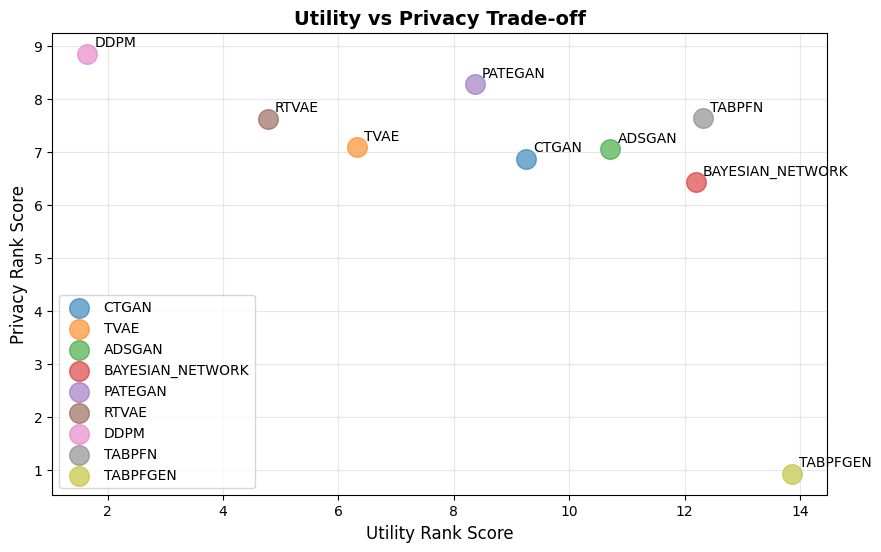

In [21]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 6))
for model in benchmark_results.index:
    u_rank = benchmark_results.loc[model, ("u_rank", "")]
    p_rank = benchmark_results.loc[model, ("p_rank", "")]
    ax.scatter(u_rank, p_rank, s=200, alpha=0.6, label=model.upper())
    ax.annotate(
        model.upper(),
        (u_rank, p_rank),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )
ax.set_xlabel("Utility Rank Score", fontsize=12)
ax.set_ylabel("Privacy Rank Score", fontsize=12)
ax.set_title("Utility vs Privacy Trade-off", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

## Test log disparity

In [22]:
import sys

sys.path.append("../scripts/log_disparity/")

from metric_log_disparity import (
    compute_log_disparity_report,
    summarize_multi_model_reports,
)

age_bins = [7, 18, 30, 45, 60, 78]

model_reports = {}
for model_name, syn_df in sorted(synthetic_datasets.items()):
    model_reports[model_name] = compute_log_disparity_report(
        real_data=train_df,
        synth_data=syn_df,
        target_col=target_column,
        protected_cols=["SEX", "AGE"],
        model_name=model_name,
        target_map={1: "died", 2: "survived"},
        protected_map=[{1: "male", 2: "female"}, None],
        target_bins=None,
        protected_bins=[None, age_bins],
    )

model_summary_df, model_label_counts, model_label_counts_pivot = (
    summarize_multi_model_reports(model_reports)
)

print("Model summary table (log disparity + significance):")
display(model_summary_df)

print("\nLeaf-level equity label counts per model:")
display(model_label_counts_pivot)

print(
    "\nPer-model fairness report figures (sunburst + styled subgroup table + color legend):"
)
for model_name in sorted(model_reports):
    print(f"\nModel: {model_name}")
    model_reports[model_name]["report_figure"].show()


Model summary table (log disparity + significance):


,model,n_subgroups,mean_abs_log_disparity,median_abs_log_disparity,share_significant_bh
6,tabpfgen,12,0.231837,0.161487,0.000000
2,ctgan,12,0.440782,0.166235,0.000000
1,bayesian_network,12,0.485084,0.400160,0.000000
7,tabpfn,19,0.512995,0.440381,0.000000
0,adsgan,12,0.574259,0.598369,0.000000
5,rtvae,12,0.727840,0.825034,0.166667
8,tvae,12,0.866380,0.970710,0.250000
4,pategan,14,0.905338,0.817946,0.071429
3,ddpm,12,2.194277,2.510353,0.083333



Leaf-level equity label counts per model:


EquityLabel,Absent,Equitable,Equitable(p),Highly Overrepresented,Highly Underrepresented,No Base Data,Underrepresented
Model,,,,,,,
adsgan,3,0,5,1,3,0,0
bayesian_network,1,0,6,4,0,0,1
ctgan,3,2,5,1,1,0,0
ddpm,7,0,0,4,1,0,0
pategan,0,0,4,5,3,2,0
rtvae,7,0,2,2,1,0,0
tabpfgen,1,1,6,1,2,0,1
tabpfn,1,0,5,4,2,7,0
tvae,7,0,2,2,1,0,0



Per-model fairness report figures (sunburst + styled subgroup table + color legend):

Model: adsgan


...


Model: pategan



Model: rtvae



Model: tabpfgen



Model: tabpfn



Model: tvae



Model: adsgan


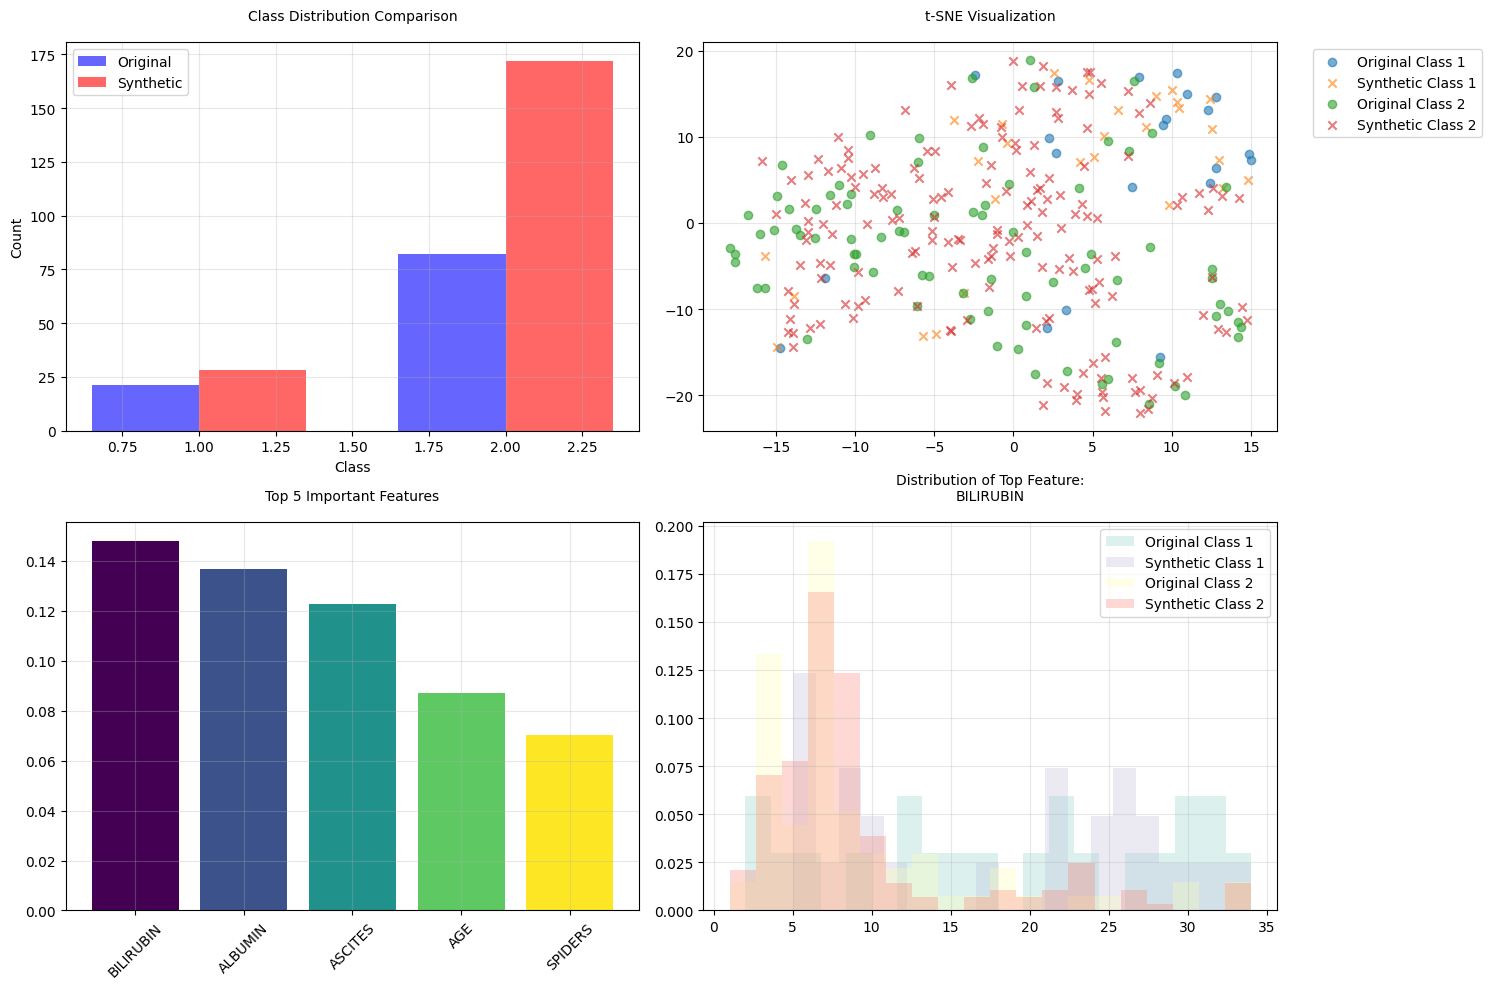

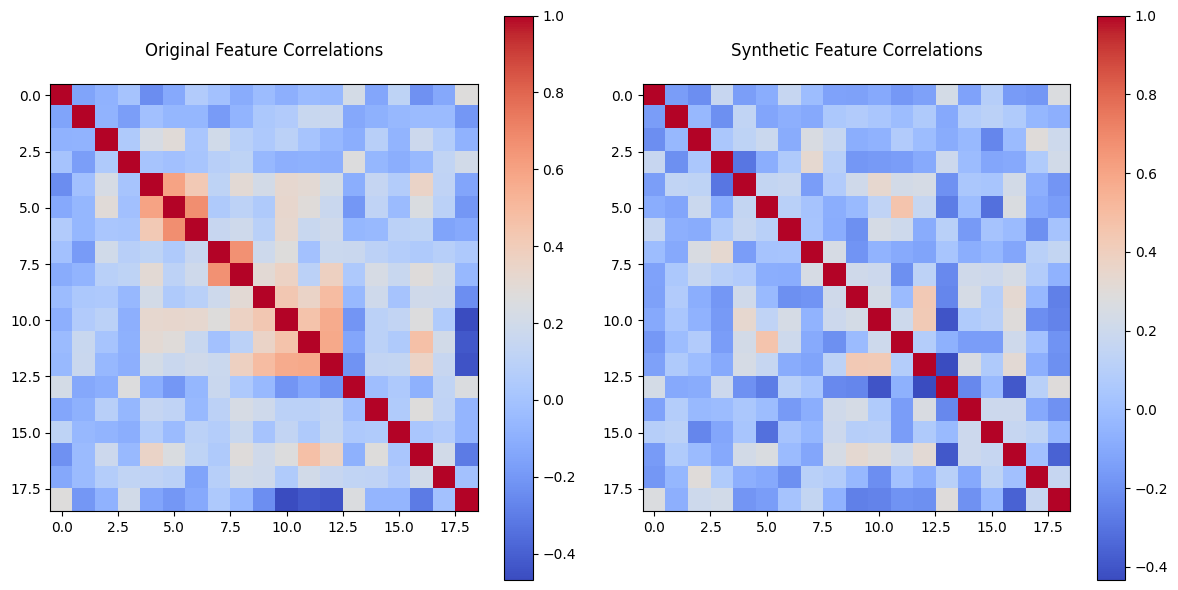


Model: bayesian_network


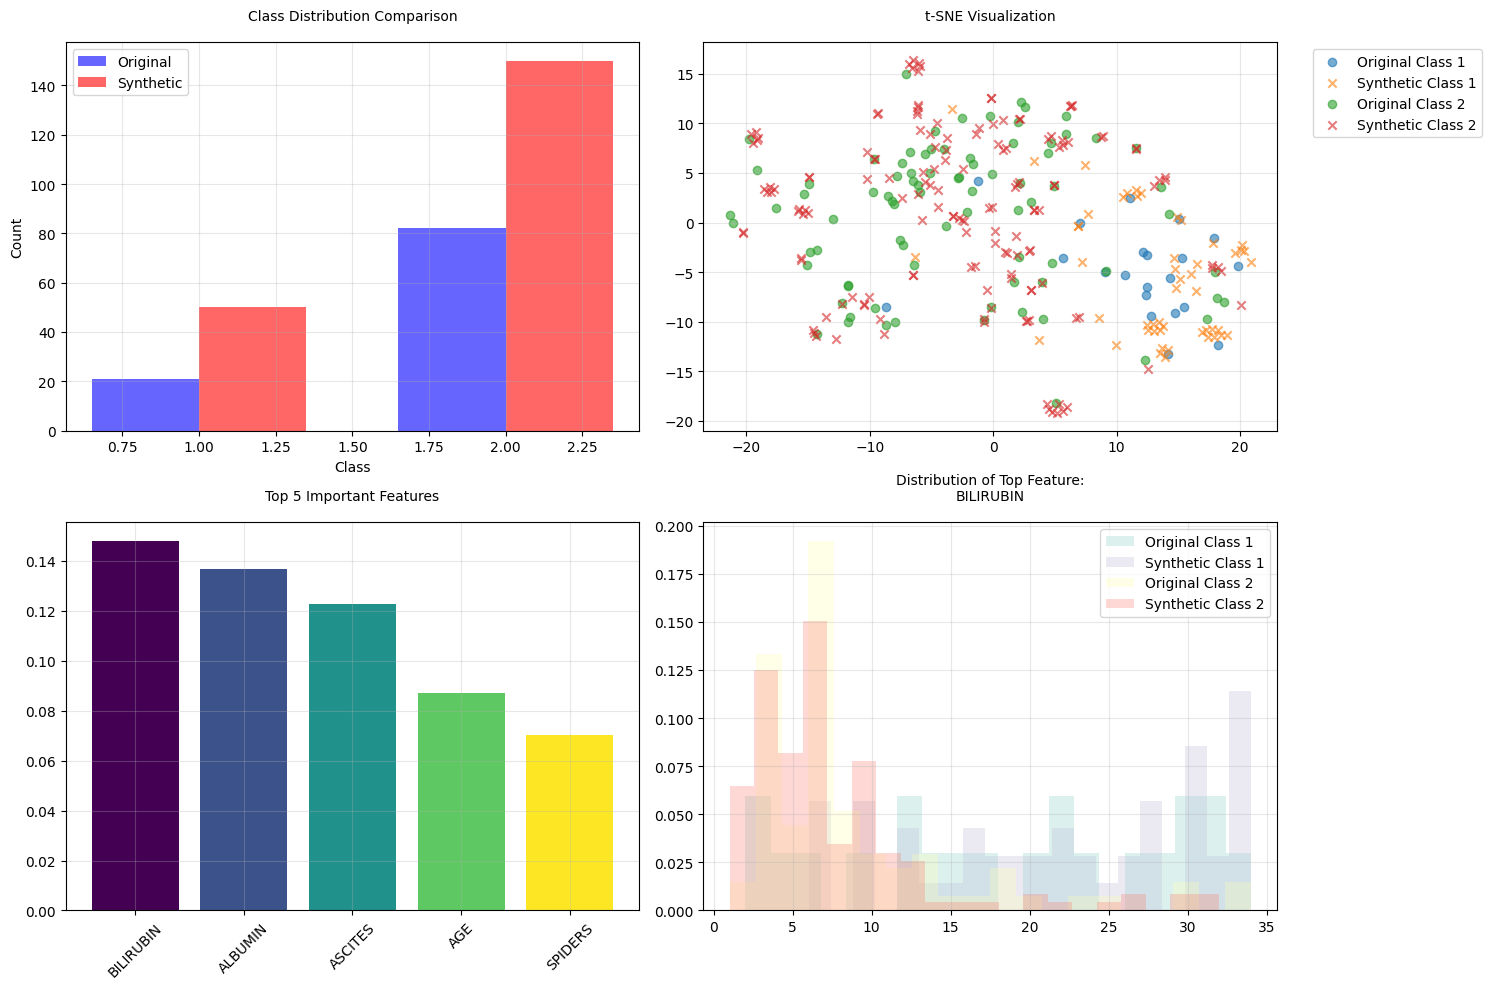

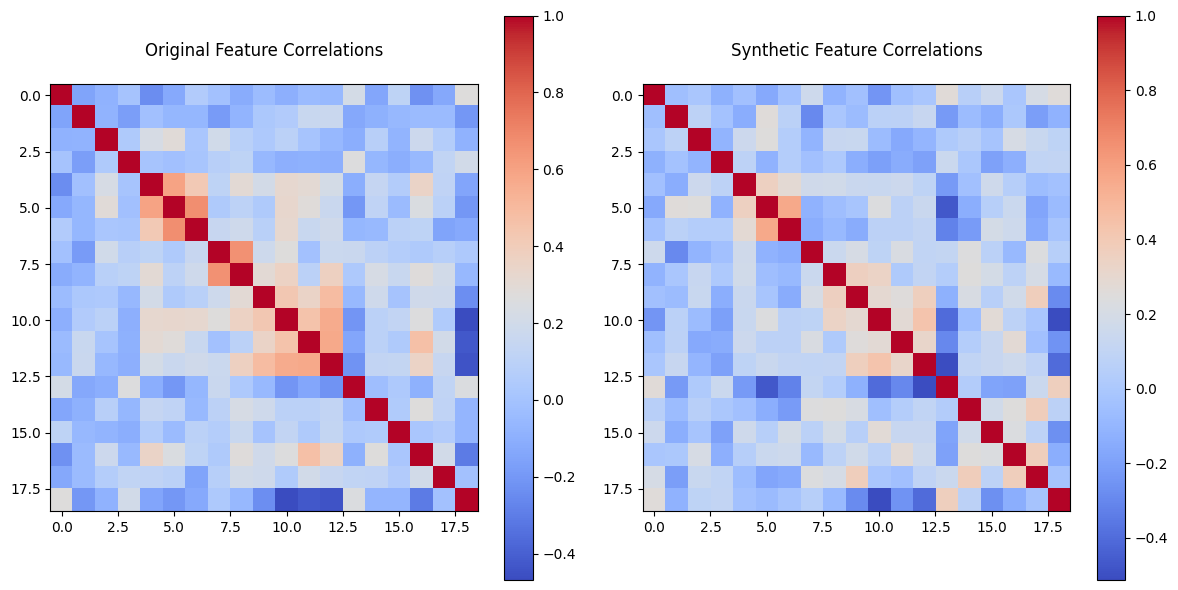


Model: ctgan


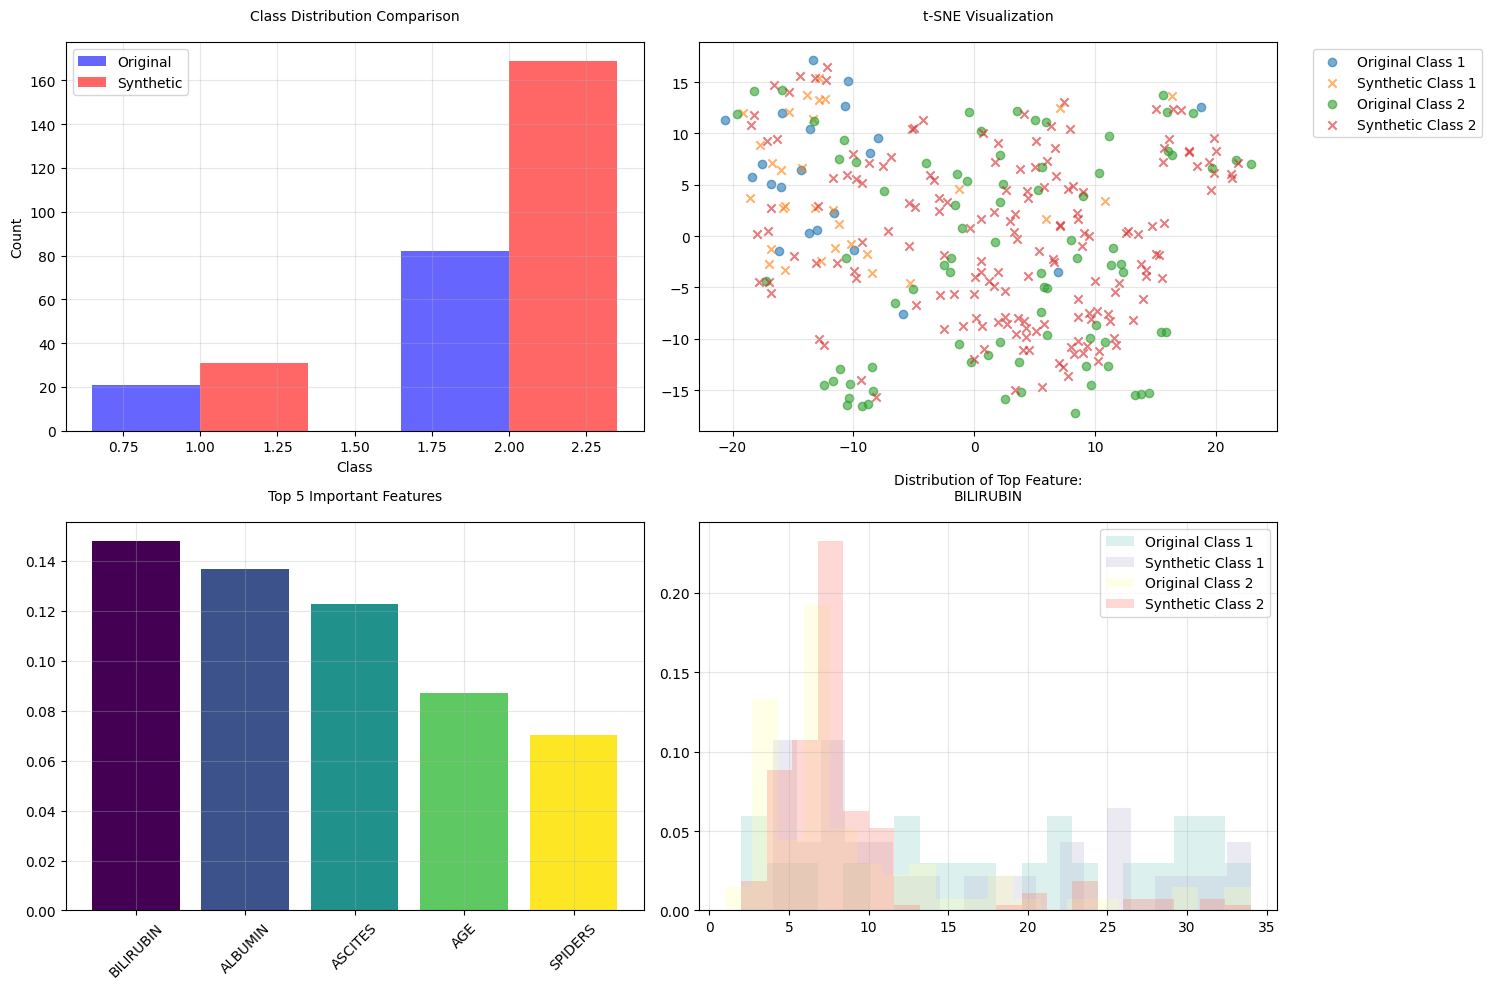

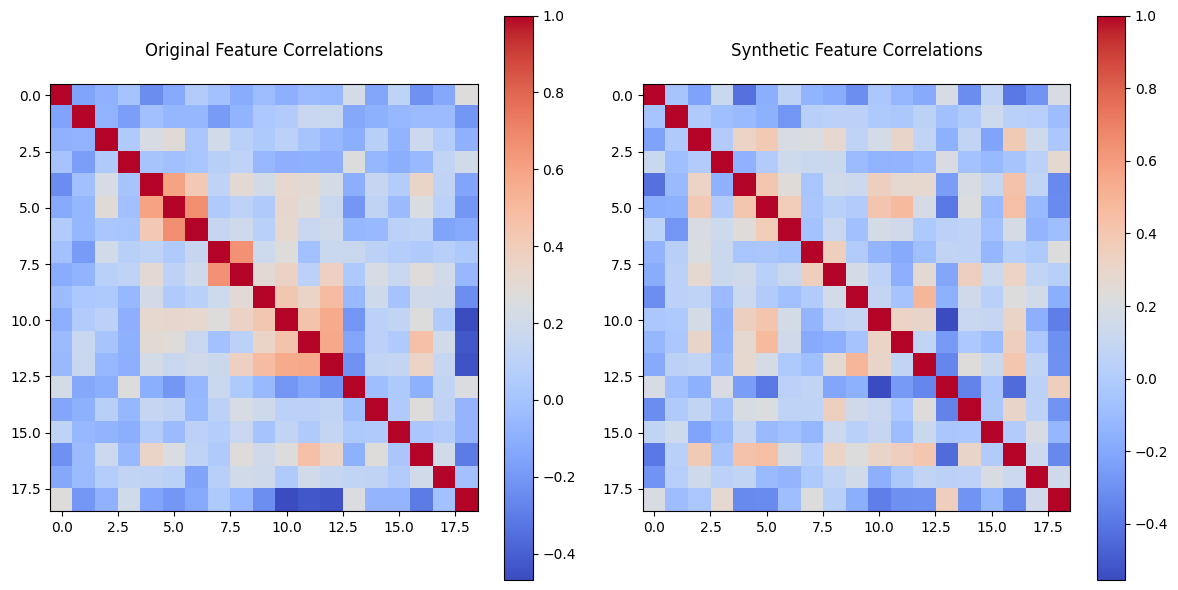


Model: ddpm


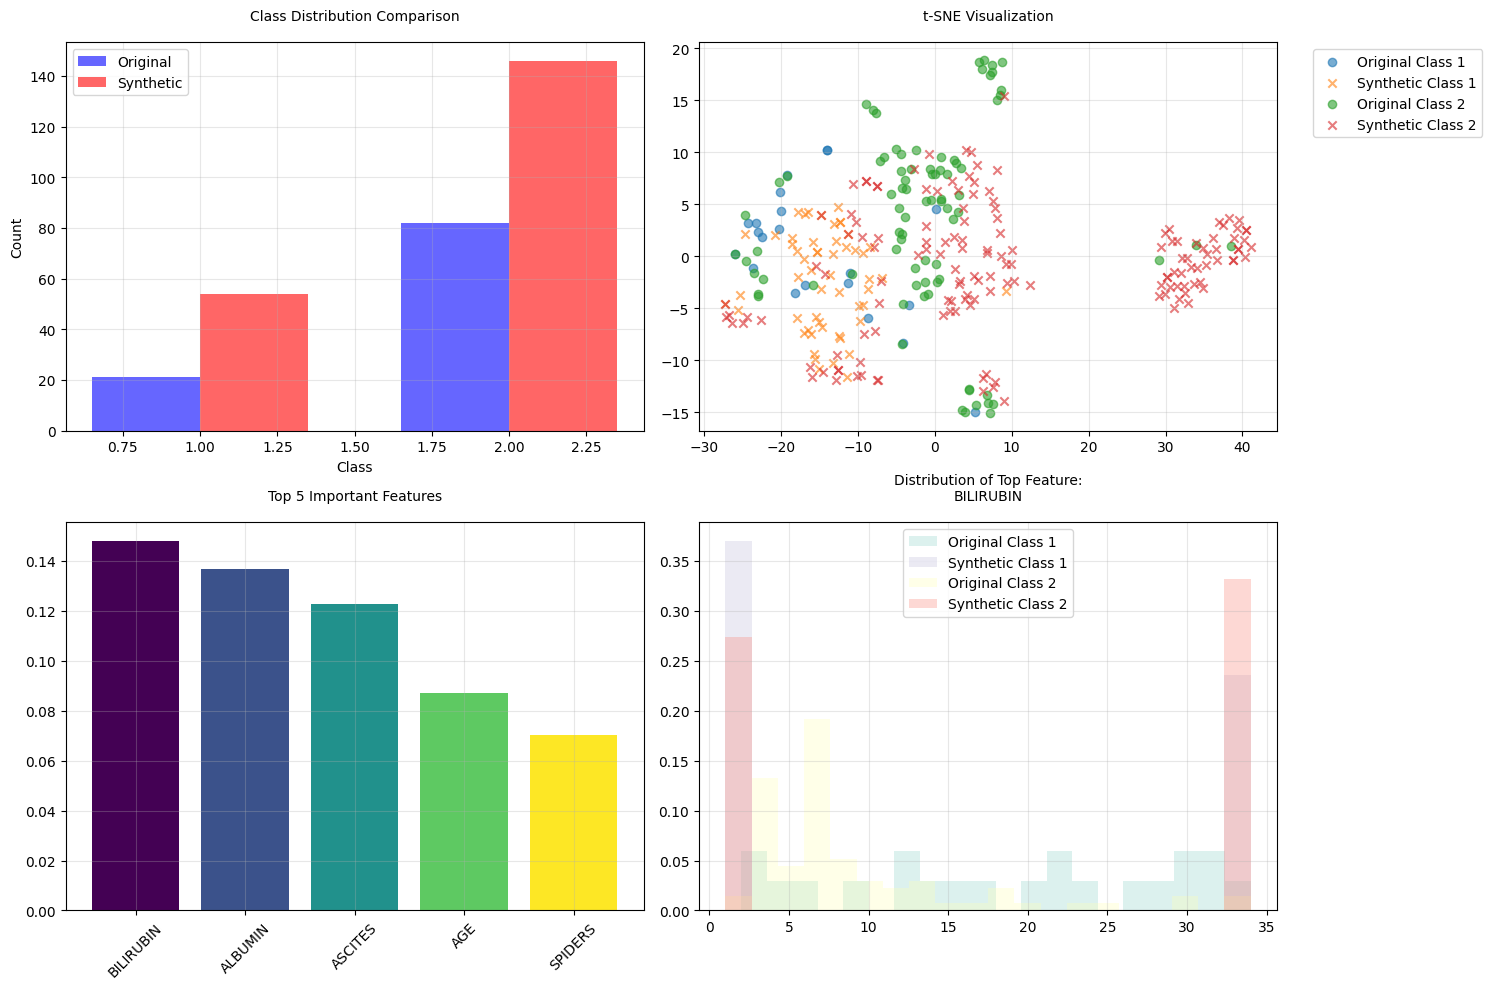

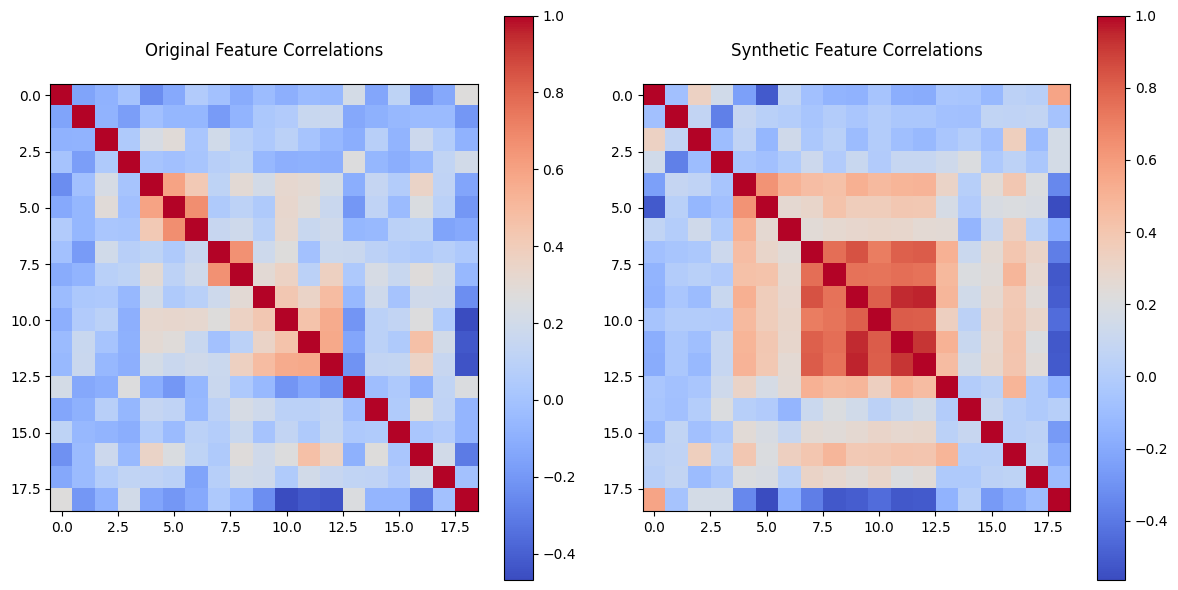


Model: pategan


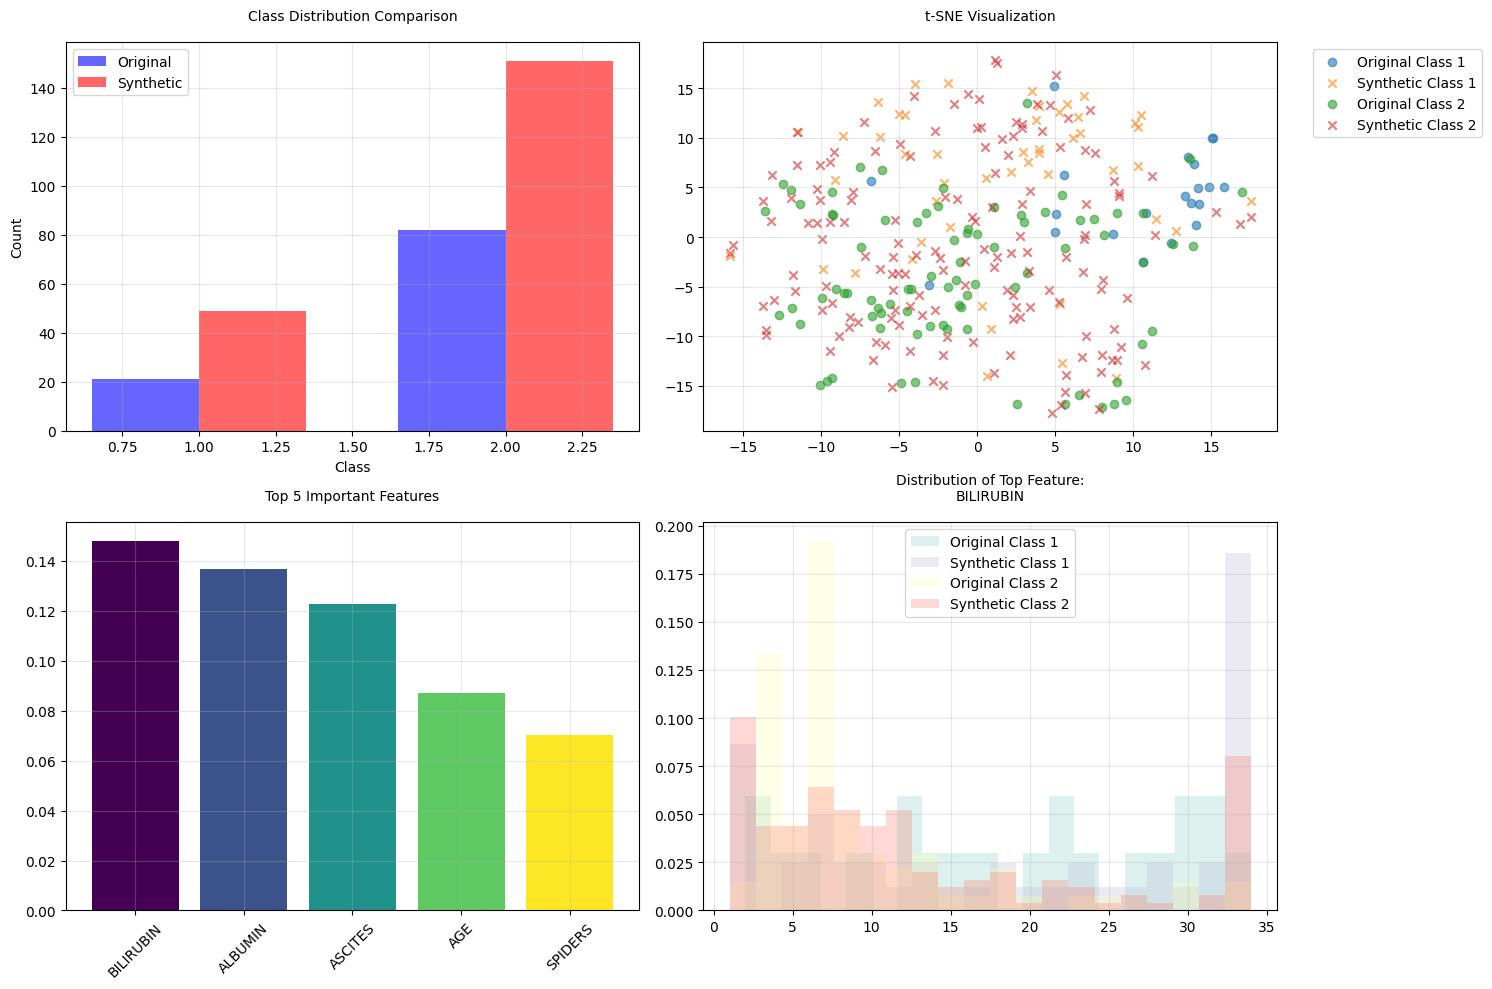

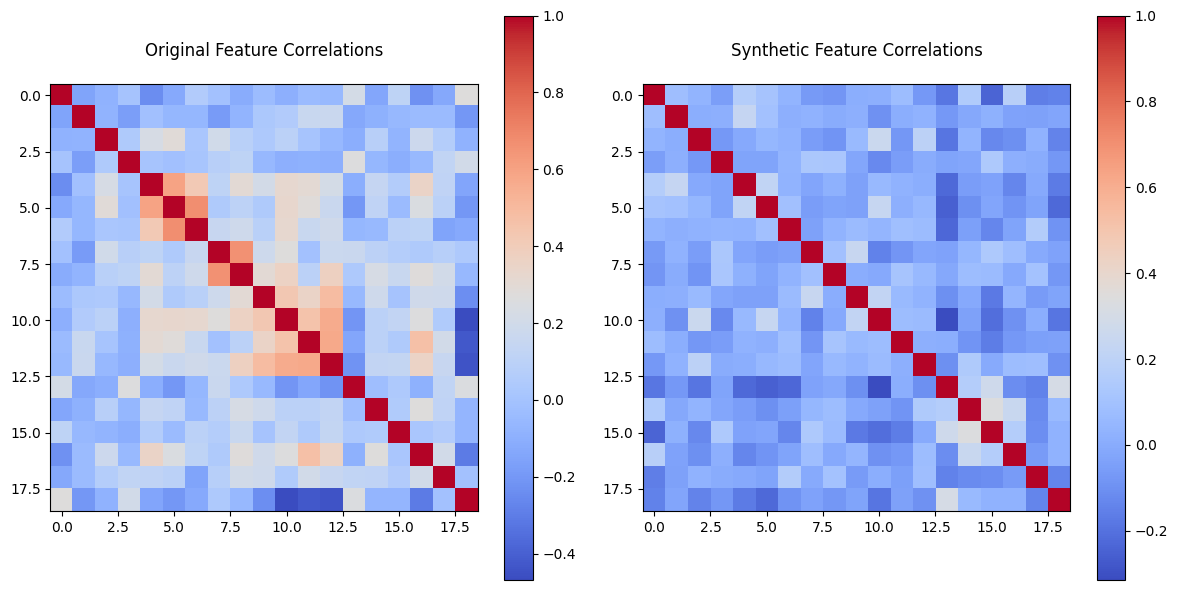


Model: rtvae


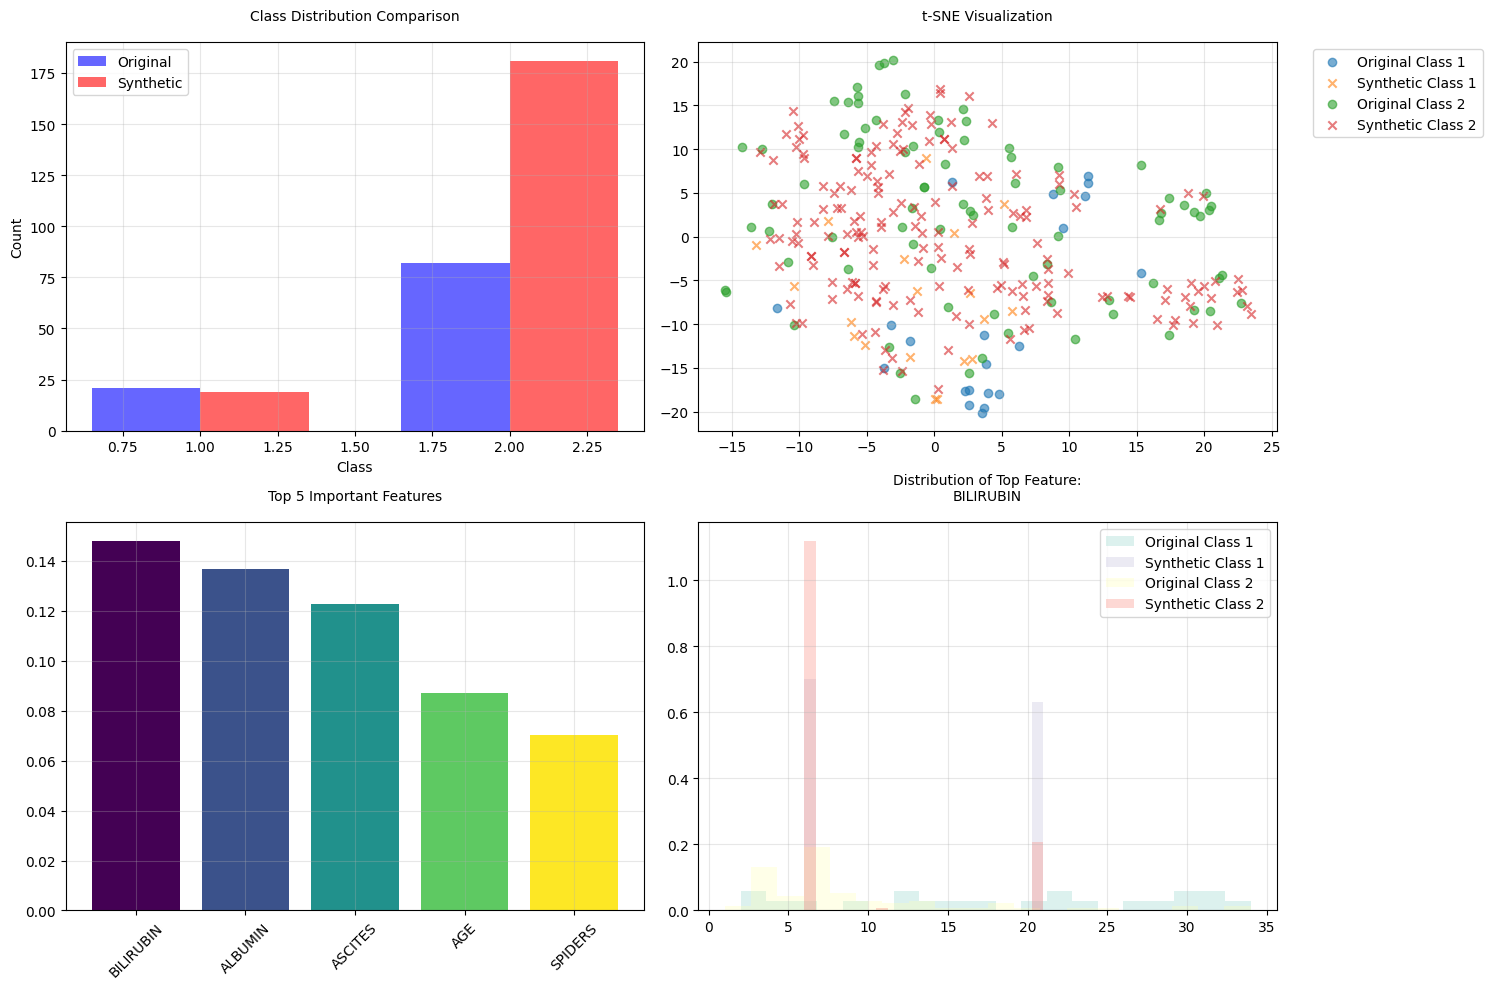

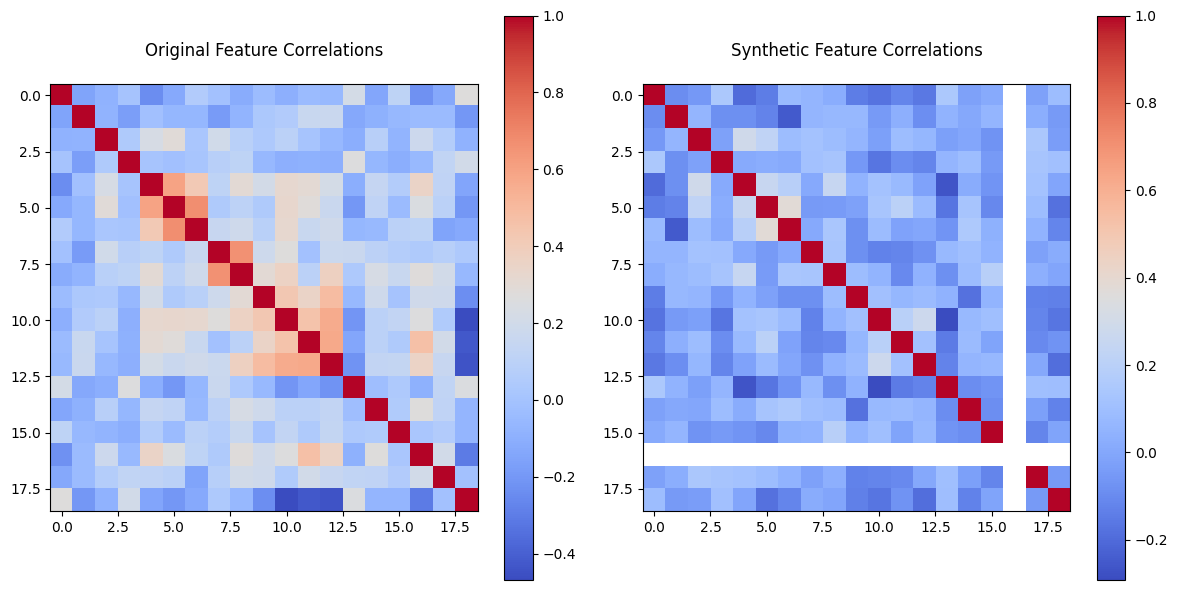


Model: tabpfgen


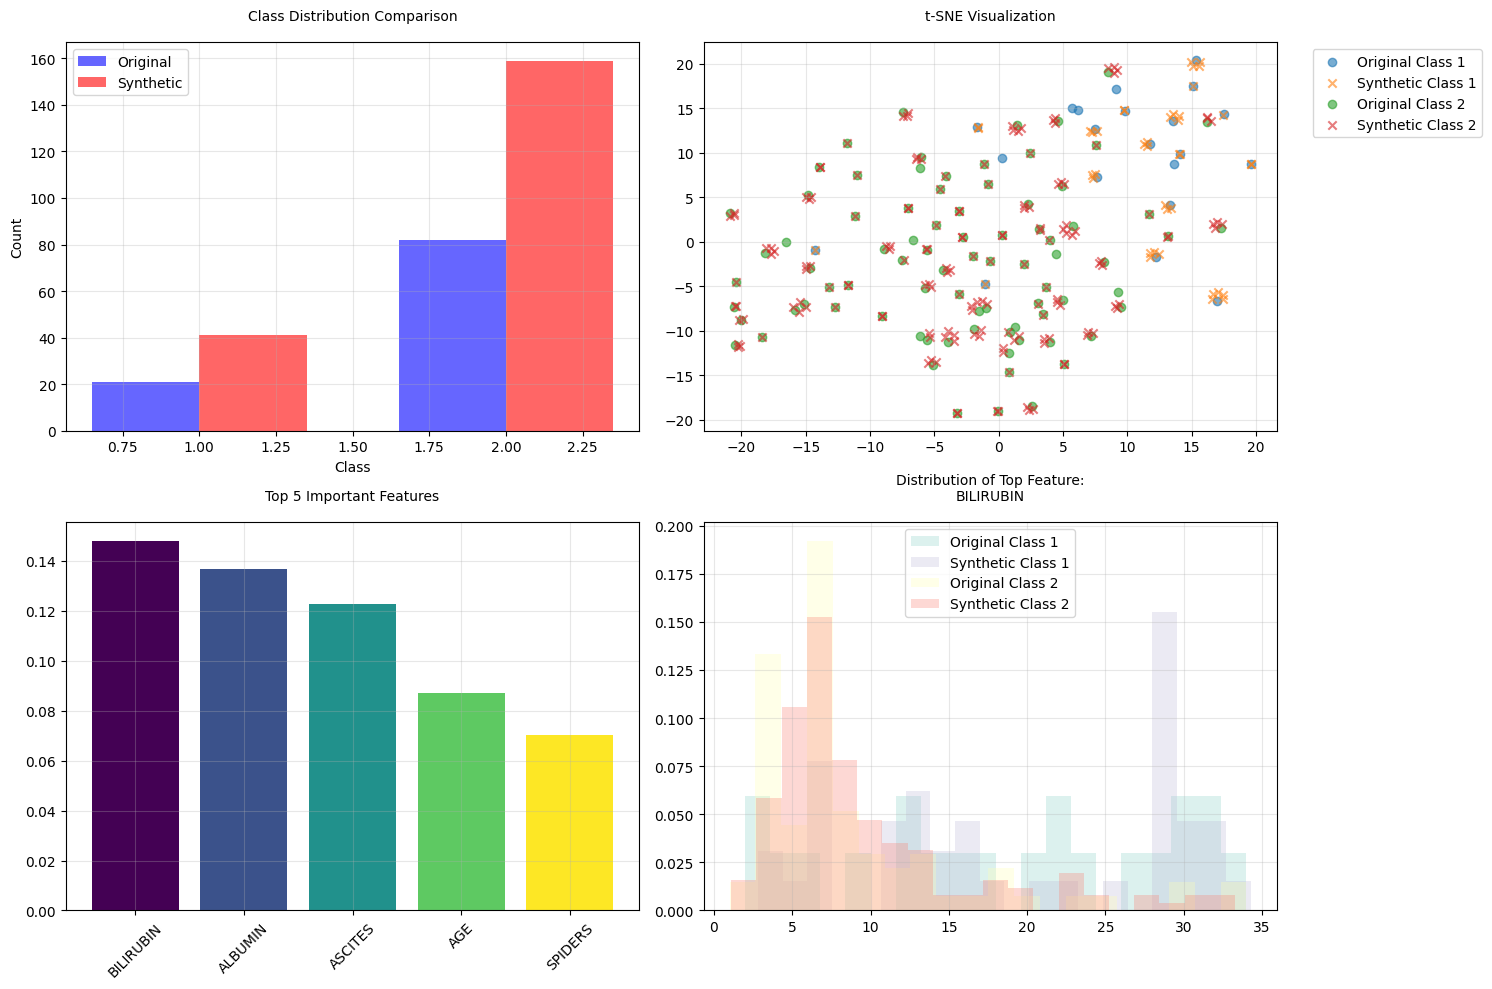

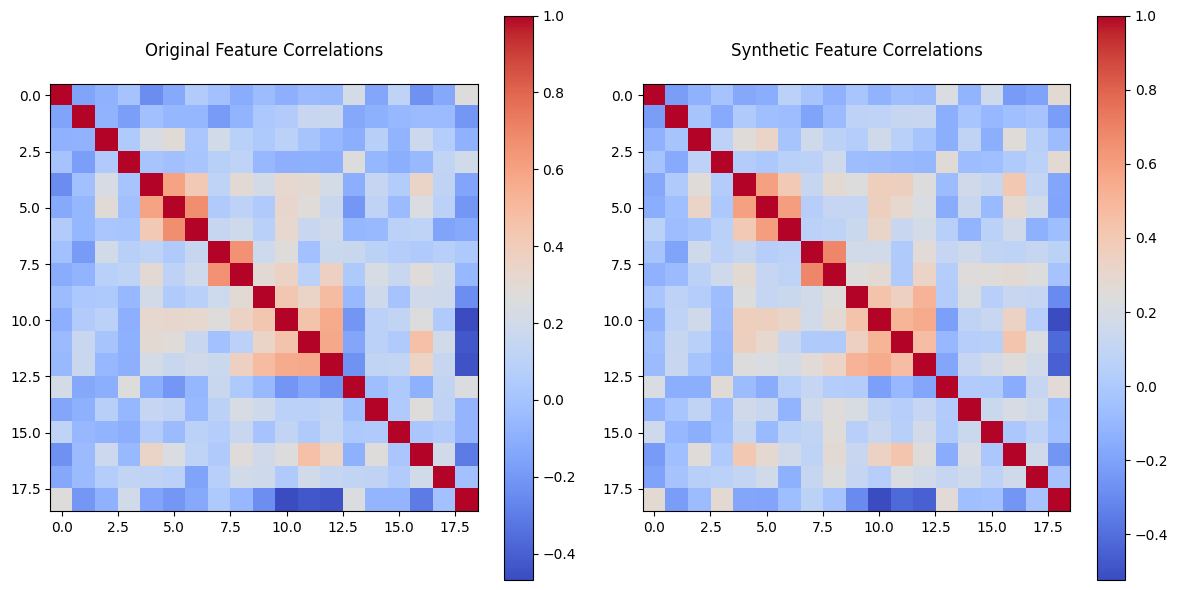


Model: tabpfn


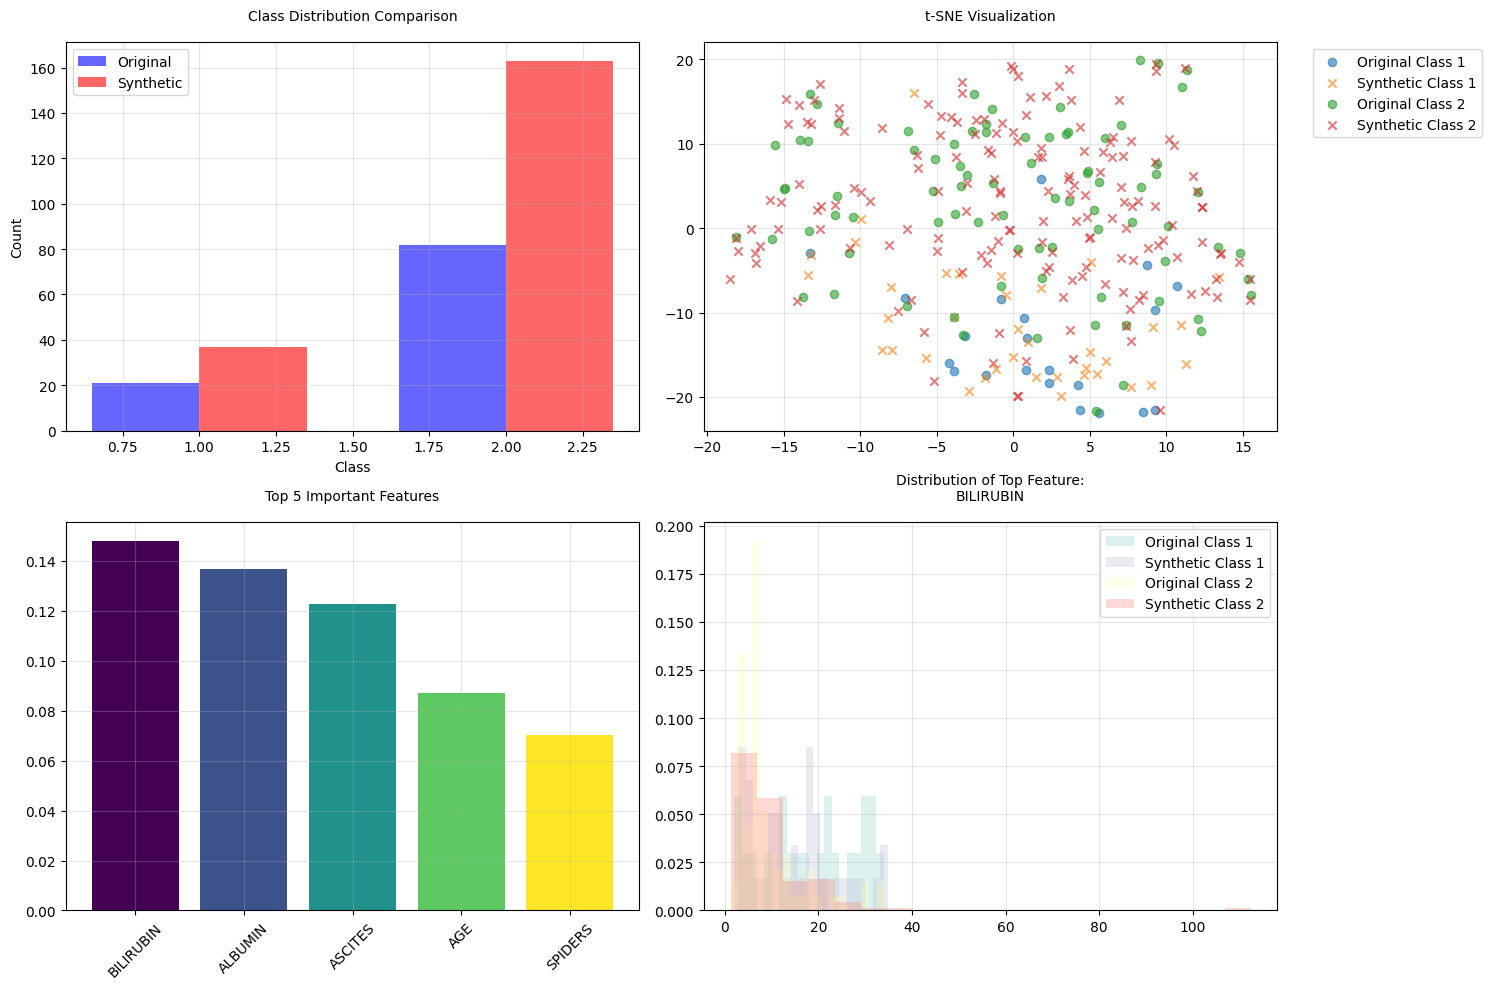

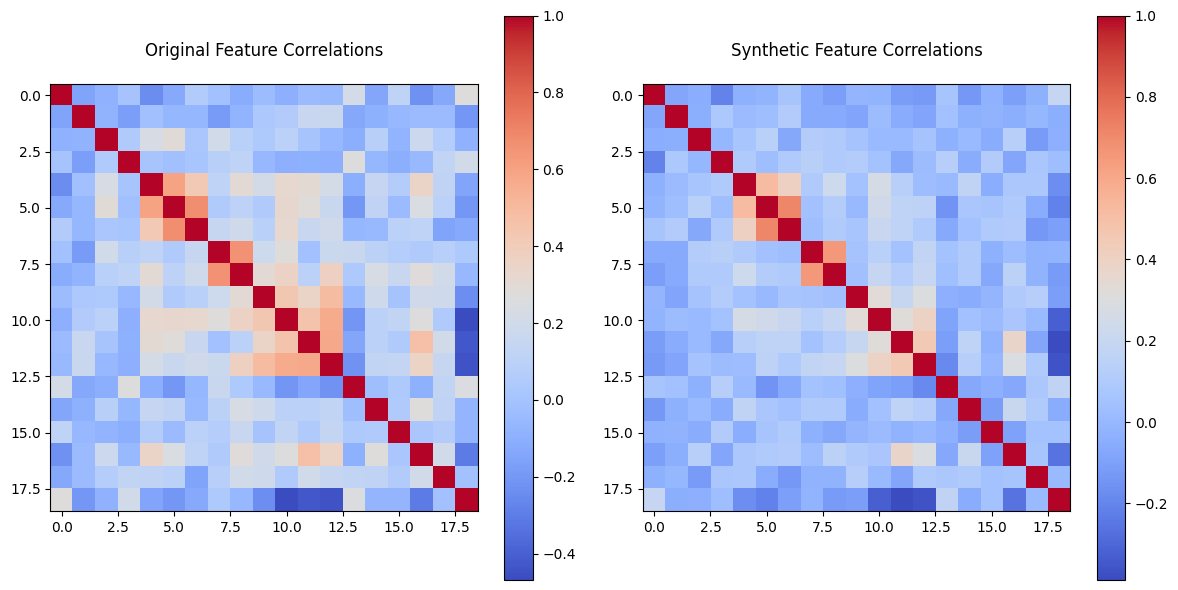


Model: tvae


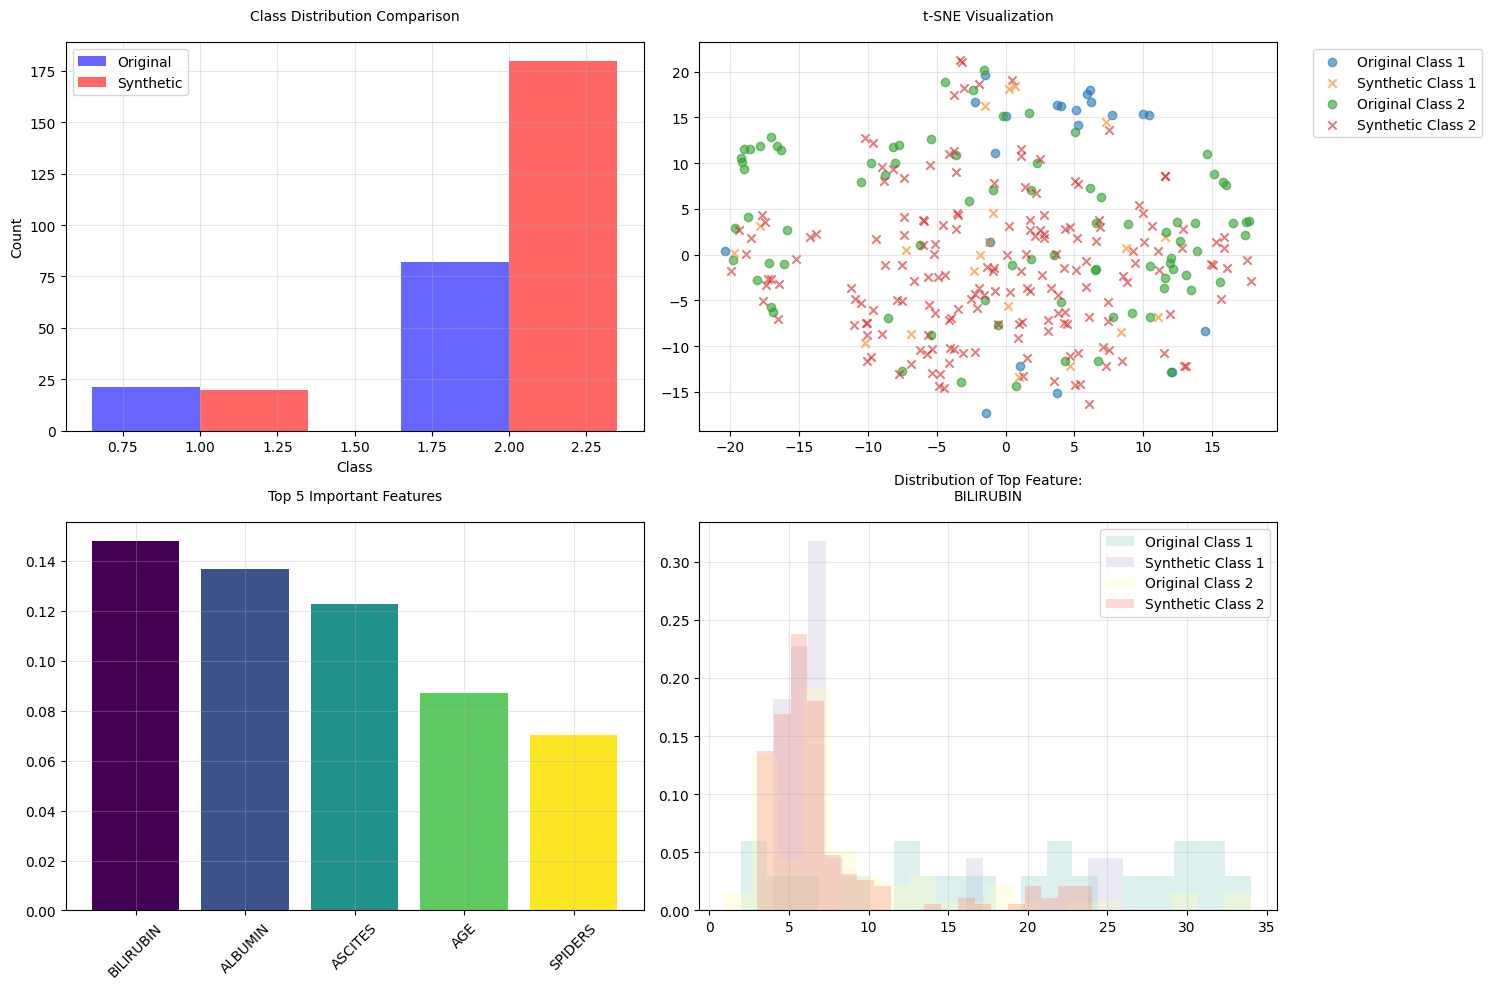

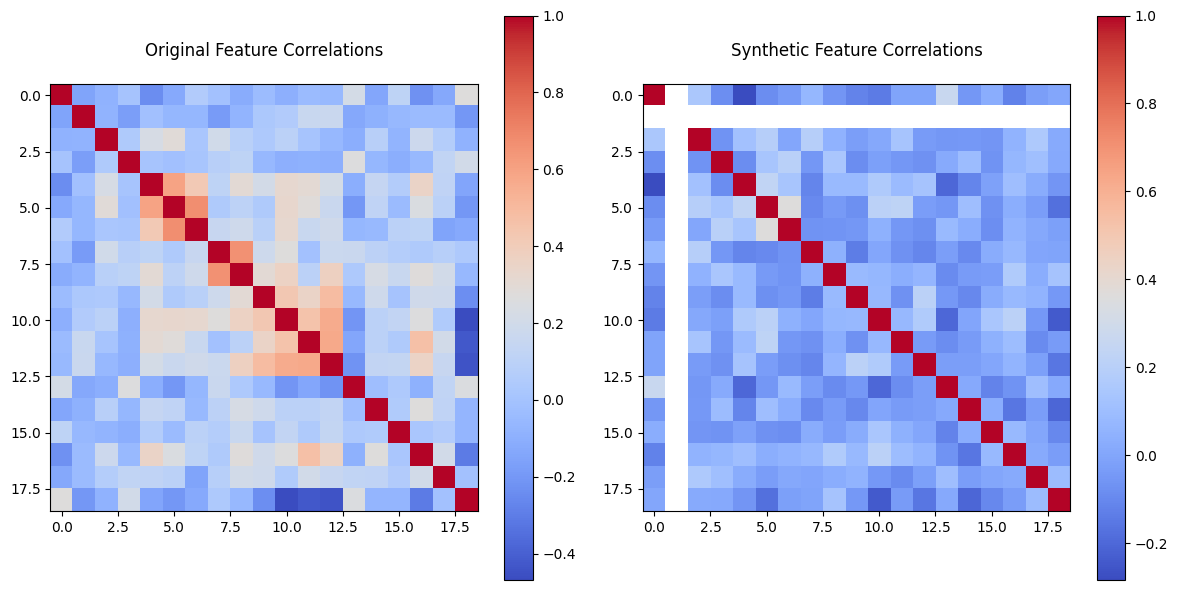

In [23]:
from tabpfgen.visuals import visualize_classification_results

# plot the classification results for each model
for model_name, syn_df in sorted(synthetic_datasets.items()):
    print(f"\nModel: {model_name}")
    visualize_classification_results(
        X_orig=train_df.drop(columns=[target_column]).values,
        y_orig=train_df[target_column].values,
        X_synth=syn_df.drop(columns=[target_column]).values,
        y_synth=syn_df[target_column].values,
        feature_names=train_df.drop(columns=[target_column]).columns.tolist(),
    )